# Анализ A/B-теста Game Forest

Период теста: 01.01.2025 – 28.02.2025

## Подход к решению

Для проверки качества данных и расчета метрик по группам был использован SQL (PostgreSQL). Для статистических тестов и проверки расчетов был использован Python (Pandas, Numpy, Scipy, Matplotlib).

## Краткое резюме
**Главный результат:** Изменение в группе B показало значимый положительный эффект на доход и вовлечённость. ARPU вырос на +9.2% (p < 0.001) за счёт увеличения чека существующих плательщиков (ARPPU +10.9%, p < 0.001), а не привлечения новых (конверсия не изменилась). Вовлечённость также выросла: время в продукте +9.4%, число сессий +6.8%. Удержание (active days) практически не изменилось.

**Рекомендация:** Внедрять изменение на 100% аудитории. Все ключевые бизнес-метрики выросли согласованно и статистически значимо, негативных эффектов не выявлено.

## Загрузка данных в Python

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

df = pd.read_csv('ab_test_data.csv')
print('Размер:', df.shape)
print('Период:', df['date'].min(), '->', df['date'].max())
df.head()

Размер: (1809362, 8)
Период: 2025-01-01 -> 2025-02-28


,user_id,date,group,revenue,time_played,sessions,transactions,first_seen
0,1,2025-01-02,A,0.0000,46.5000,2,0,2024-05-20
1,1,2025-01-03,A,0.0000,68.6000,1,0,2024-05-20
2,1,2025-01-04,A,0.0000,49.2000,1,0,2024-05-20
3,1,2025-01-11,A,0.0000,71.9000,3,0,2024-05-20
4,1,2025-01-13,A,0.0000,49.5000,2,0,2024-05-20


## Проверка качества данных

### SQL-запросы (PostgreSQL)

```sql
-- Баланс групп: уникальные пользователи в A и B
SELECT "group", COUNT(DISTINCT user_id) AS users
FROM ab_test_data
GROUP BY "group";

-- Контаминация: пользователи в обеих группах (ожидаем 0)
SELECT user_id, COUNT(DISTINCT "group") AS group_count
FROM ab_test_data
GROUP BY user_id
HAVING COUNT(DISTINCT "group") > 1;

-- Аномалии: отрицательный доход (ожидаем 0)
SELECT COUNT(*) AS negative_revenue
FROM ab_test_data
WHERE revenue < 0;
```

**Результаты SQL:** A = 49 897 пользователей, B = 50 103, контаминация = 0, отрицательного дохода нет.

### Кросс-проверка в Python

In [2]:
# Пропуски (в SQL ожидали: 0 по всем столбцам)
print('Пропуски:', df.isnull().sum().sum(), '(ожидали 0)')

# Баланс групп (в SQL: A = 49897, B = 50103)
users_per_group = df.groupby('group')['user_id'].nunique()
print(users_per_group)

# Контаминация (в SQL: 0)
multi = df.groupby('user_id')['group'].nunique()
print('Пользователей более чем в одной группе:', (multi > 1).sum())

# 2.4 Аномалии
print('revenue < 0:', (df['revenue'] < 0).sum())

Пропуски: 0 (ожидали 0)
group
A    49897
B    50103
Name: user_id, dtype: int64
Пользователей более чем в одной группе: 0
revenue < 0: 0


Кросс-проверка пройдена, поскольку результаты Python совпадают с SQL

## Метрики

- APRU — главная бизнес-метрика дохода на пользователя
- Conversion — не оттолкнуло ли изменение часть платящей аудитории
- ARPPU — средний доход на платящего пользователя
- Time played per user — глубина вовлечения
- Sessions per user — частота возврата в продукт
- Active days per user — число дней с активностью (частота возвращения в продукт)

## Агрегация до уровня пользователя

### SQL-запрос (CTE, переиспользуется в следующих запросах)

```sql
WITH per_user AS (
    SELECT
        user_id,
        "group",
        SUM(revenue)            AS revenue,
        SUM(time_played)        AS time_played,
        SUM(sessions)           AS sessions,
        COUNT(DISTINCT date)    AS active_days,
        (SUM(revenue) > 0)::int AS is_payer
    FROM ab_test_data
    GROUP BY user_id, "group"
)
SELECT * FROM per_user LIMIT 5;
```

### Тот же расчeт в Python

In [3]:
user = (df.groupby(['user_id', 'group'])
          .agg(revenue=('revenue', 'sum'),
               time_played=('time_played', 'sum'),
               sessions=('sessions', 'sum'),
               active_days=('date', 'nunique'))
          .reset_index())

user['is_payer'] = (user['revenue'] > 0).astype(int)

A = user[user['group'] == 'A']
B = user[user['group'] == 'B']
print(f'Пользователей: A = {len(A)}, B = {len(B)}')
user.head()

Пользователей: A = 49897, B = 50103


,user_id,group,revenue,time_played,sessions,active_days,is_payer
0,1,A,0.0000,1192.4000,35,21,0
1,2,B,0.0000,1232.1000,36,19,0
2,3,B,0.0000,1140.8000,37,18,0
3,4,A,0.0000,1259.7000,55,22,0
4,5,A,0.0000,995.8000,45,19,0


## Кросс-проверка метрик: Python и SQL

### SQL-запрос

```sql
WITH per_user AS (
    SELECT user_id, "group",
           SUM(revenue)            AS revenue,
           SUM(time_played)        AS time_played,
           SUM(sessions)           AS sessions,
           COUNT(DISTINCT date)    AS active_days,
           (SUM(revenue) > 0)::int AS is_payer
    FROM ab_test_data
    GROUP BY user_id, "group"
)
SELECT
    "group",
    COUNT(*)                                                    AS users,
    ROUND(AVG(revenue)::numeric, 4)                             AS arpu,
    ROUND(AVG(is_payer)::numeric, 4)                            AS conversion,
    ROUND(AVG(revenue) FILTER (WHERE is_payer = 1)::numeric, 4) AS arppu,
    ROUND(AVG(time_played)::numeric, 2)                         AS avg_time_played,
    ROUND(AVG(sessions)::numeric, 2)                            AS avg_sessions,
    ROUND(AVG(active_days)::numeric, 2)                         AS avg_active_days
FROM per_user
GROUP BY "group"
ORDER BY "group";
```

### Сверка с Python

Сводим в одну таблицу результаты SQL и Python, считаем разницу. Если различия близки к нулю, то расчеты обоих инструментов совпадают.

In [4]:
# Числа из SQL
sql_results = pd.DataFrame({
    'metric':   ['ARPU',   'Conversion', 'ARPPU',  'time_played', 'sessions', 'active_days'],
    'A_sql':    [5.4523,    0.1659,      32.8567,  1088.74,        34.12,      18.15],
    'B_sql':    [5.9544,    0.1635,      36.4220,  1190.65,        36.43,      18.04],
})

# Те же метрики, но посчитанные в Python
python_results = pd.DataFrame({
    'metric': ['ARPU', 'Conversion', 'ARPPU', 'time_played', 'sessions', 'active_days'],
    'A_py': [
        A['revenue'].mean(),
        A['is_payer'].mean(),
        A.loc[A['is_payer'] == 1, 'revenue'].mean(),
        A['time_played'].mean(),
        A['sessions'].mean(),
        A['active_days'].mean(),
    ],
    'B_py': [
        B['revenue'].mean(),
        B['is_payer'].mean(),
        B.loc[B['is_payer'] == 1, 'revenue'].mean(),
        B['time_played'].mean(),
        B['sessions'].mean(),
        B['active_days'].mean(),
    ],
})

# Сводим в одну таблицу и считаем расхождение
check = sql_results.merge(python_results, on='metric')
check['A_diff'] = (check['A_py'] - check['A_sql']).round(4)
check['B_diff'] = (check['B_py'] - check['B_sql']).round(4)
check

,metric,A_sql,B_sql,A_py,B_py,A_diff,B_diff
0,ARPU,5.4523,5.9544,5.4523,5.9544,0.0000,-0.0000
1,Conversion,0.1659,0.1635,0.1659,0.1635,0.0000,-0.0000
2,ARPPU,32.8567,36.4220,32.8567,36.4220,0.0000,0.0000
3,time_played,1088.7400,1190.6500,1088.7367,1190.6462,-0.0033,-0.0038
4,sessions,34.1200,36.4300,34.1243,36.4268,0.0043,-0.0032
5,active_days,18.1500,18.0400,18.1454,18.0421,-0.0046,0.0021


Столбцы `A_diff` и `B_diff` близки к нулю (с точностью до округления), значит расчёты SQL и Python совпадают, метрикам можно доверять.

## Статистические тесты

Методы:
- Welch's t-test — для метрик-средних (revenue, time_played, sessions, active_days, ARPPU), не требует равенства дисперсий
- z-тест для долей — для конверсии (бинарная метрика)
- Mann–Whitney U — непараметрическая проверка устойчивости для revenue

Порог значимости: α = 0.05.

### Welch's t-test для метрик-средних

In [5]:
def lift_pct(a, b):
    return (b - a) / a * 100

results = []
for col, label in [('revenue', 'ARPU'), ('time_played', 'time_played'),
                   ('sessions', 'sessions'), ('active_days', 'active_days')]:
    mean_a, mean_b = A[col].mean(), B[col].mean()
    t_stat, p_val = stats.ttest_ind(B[col], A[col], equal_var=False)
    results.append({
        'metric': label,
        'A': round(mean_a, 4),
        'B': round(mean_b, 4),
        'lift_%': round(lift_pct(mean_a, mean_b), 2),
        'p_value': p_val,
        'significant (a=0.05)': p_val < 0.05,
    })

pd.DataFrame(results)

,metric,A,B,lift_%,p_value,significant (a=0.05)
0,ARPU,5.4523,5.9544,9.2100,0.0000,True
1,time_played,1088.7367,1190.6462,9.3600,0.0000,True
2,sessions,34.1243,36.4268,6.7500,0.0000,True
3,active_days,18.1454,18.0421,-0.5700,0.0189,True


### z-тест для долей 

В SQL уже получили `z = -1.048`, что означает «разница не значима». Перепроверяем в Python:

In [6]:
x_a, n_a = A['is_payer'].sum(), len(A)
x_b, n_b = B['is_payer'].sum(), len(B)
conv_a, conv_b = x_a / n_a, x_b / n_b

p_pool = (x_a + x_b) / (n_a + n_b)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
z = (conv_b - conv_a) / se
p_val_conv = 2 * (1 - stats.norm.cdf(abs(z)))

print(f'Conversion A = {conv_a:.4f} ({conv_a*100:.2f}%)')
print(f'Conversion B = {conv_b:.4f} ({conv_b*100:.2f}%)')
print(f'Lift = {lift_pct(conv_a, conv_b):+.2f}%')
print(f'z = {z:.3f}  (в SQL получили: -1.048)')
print(f'p-value = {p_val_conv:.4g}')
print(f'Значимо: {p_val_conv < 0.05}')

Conversion A = 0.1659 (16.59%)
Conversion B = 0.1635 (16.35%)
Lift = -1.48%
z = -1.048  (в SQL получили: -1.048)
p-value = 0.2946
Значимо: False


### ARPPU — t-тест по платящим пользователям

In [7]:
payers_a = A.loc[A['is_payer'] == 1, 'revenue']
payers_b = B.loc[B['is_payer'] == 1, 'revenue']

t_stat, p_arppu = stats.ttest_ind(payers_b, payers_a, equal_var=False)
print(f'ARPPU A = {payers_a.mean():.3f}  (платящих: {len(payers_a)})')
print(f'ARPPU B = {payers_b.mean():.3f}  (платящих: {len(payers_b)})')
print(f'Lift = {lift_pct(payers_a.mean(), payers_b.mean()):+.2f}%')
print(f'p-value = {p_arppu:.4g},  значимо: {p_arppu < 0.05}')

ARPPU A = 32.857  (платящих: 8280)
ARPPU B = 36.422  (платящих: 8191)
Lift = +10.85%
p-value = 2.953e-19,  значимо: True


### Mann–Whitney U — проверка устойчивости

Доход (revenue) сильно скошен и содержит много нулей. T-тест может быть чувствителен к этому, поэтому проверяем непараметрическим тестом, который сравнивает распределения, а не средние.

In [8]:
u_stat, p_mw = stats.mannwhitneyu(B['revenue'], A['revenue'], alternative='two-sided')
print(f'Mann-Whitney U p-value = {p_mw:.4g}')
print(f'Медиана revenue среди платящих:  A = {payers_a.median():.2f}  |  B = {payers_b.median():.2f}')

Mann-Whitney U p-value = 0.8932
Медиана revenue среди платящих:  A = 26.89  |  B = 29.95


## Визуализация

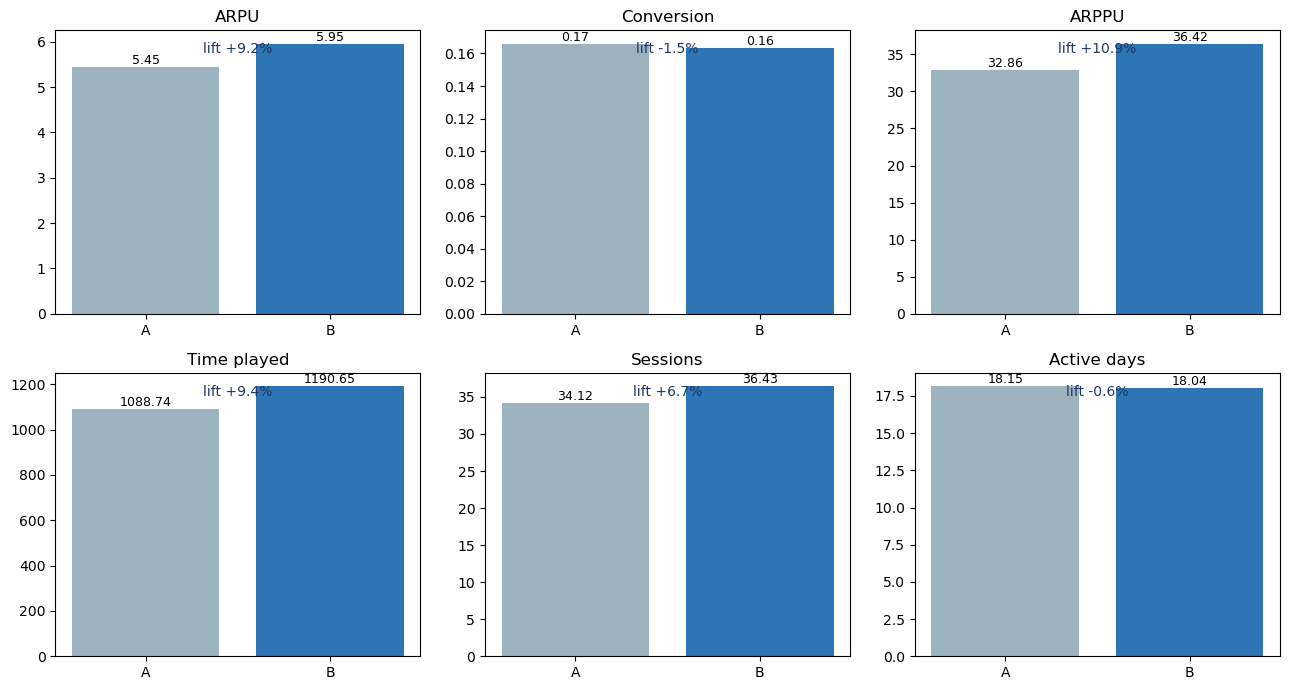

In [9]:
metrics_viz = {
    'ARPU':        (A['revenue'].mean(),     B['revenue'].mean()),
    'Conversion':  (A['is_payer'].mean(),    B['is_payer'].mean()),
    'ARPPU':       (payers_a.mean(),         payers_b.mean()),
    'Time played': (A['time_played'].mean(), B['time_played'].mean()),
    'Sessions':    (A['sessions'].mean(),    B['sessions'].mean()),
    'Active days': (A['active_days'].mean(), B['active_days'].mean()),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (name, (va, vb)) in zip(axes.flat, metrics_viz.items()):
    bars = ax.bar(['A', 'B'], [va, vb], color=['#9DB4C0', '#2E75B6'])
    ax.set_title(name)
    delta = (vb - va) / va * 100
    ax.text(0.5, 0.92, f'lift {delta:+.1f}%', transform=ax.transAxes,
            ha='center', fontsize=10, color='#1F3864')
    for b, v in zip(bars, [va, vb]):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Выводы и рекомендация

### Есть ли значимое влияние изменения?

Да, изменение оказало значимое влияние на ключевые бизнес-метрики.

| Метрика | A | B | Lift | p-value | Значимо |
|---|---|---|---|---|---|
| ARPU | 5.45 | 5.95 | +9.21% | 1.49e-06 | да |
| Conversion | 16.59% | 16.35% | −1.48% | 0.295 | нет |
| ARPPU | 32.86 | 36.42 | +10.85% | 2.95e-19 | да |
| Time played | 1088.7 | 1190.6 | +9.36% | <1e-200 | да |
| Sessions | 34.12 | 36.43 | +6.75% | <1e-100 | да |
| Active days | 18.15 | 18.04 | −0.57% | 0.019 | да, (незначительно) |
| Mann–Whitney (revenue) | — | — | — | 0.893 | нет |

- ARPU вырос на +9.21%
- Conversion изменилась незначительно, доля платящих осталась прежней
- ARPPU вырос на +10.85%, значимый рост среднего чека
- Вовлечённость выросла, время в продукте увеличилось на 9.36% , а число сессий на 6.75% 
- Удержание (active days) уменьшилось на 0.57%, величина эффекта мала (0.1 дня за 2 месяца) и не имеет продуктового значения

Поскольку конверсия не изменилась, можно сделать вывод, что рост дохода в группе B обусловлен увеличением среднего чека существующих плательщиков, а не привлечением новых. Кроме того выросла вовлеченность. Пользователи из группы B проводят больше времени в продукте и создают больше сессий в сравнении с группой A при той же частоте возвращений (active days).

### Стоит ли рекомендовать к внедрению?

На основании проведенного теста, рекомендую изменение к внедрению.

- Все ключевые бизнес-метрики (ARPU, ARPPU, time played, sessions) выросли
- Негативных эффектов не выявлено (единственное снижение active days имеет ничтожную величину, продуктового риска не несёт)
- Вовлечённость пользователей возросла, они проводят в продукте больше времени за визит, а также платящие пользователи тратят больше

## Рекомендации

- Стоит проверить динамику по неделям. Возможно мы наблюдаем эффект новизны и важно убедиться, не затухает ли динамика к концу периода.
- Стоит проверить, что рост ARPPU идёт не только за счет крупных плательщиков, а распределен по разным группам.
- Стоит разделить пользователей на новых и старых и проверить, что эффект работает для обеих групп.
- Текущее изменение увеличило средний чек, но не привлекло новых клиентов. Следует акцентировать внимание на этой метрике и протестировать гипотезы, направленные на привлечение новых пользователей. 
